In [1]:
from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_groq import ChatGroq
from dotenv import load_dotenv

In [2]:
load_dotenv()

True

In [3]:
llm = ChatGroq(
    model="openai/gpt-oss-120b"
)

In [ ]:
from langgraph.graph.message import add_messages

class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

# BaseMessage = user message + AI message


### Why is add_messages there?
- add_messages is a reducer for the messages field in your LangGraph state.
- Normally, when a node returns a new value for a state field, LangGraph may overwrite the existing value.
- But for a chat history, you usually want existing messages + New messages rather than existing messages → replaced by New messages
- So messages: Annotated[list[BaseMessage], add_messages]
- basically tells LangGraph: Whenever a node updates messages, use add_messages to merge the old and new messages instead of simply replacing the list."

In [6]:
def chat_node(state: ChatState):
    # take user query from state
    messages = state['messages']

    # send to llm
    response = llm.invoke(messages)

    # response store state
    return {'messages': [response]}

In [7]:
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile()

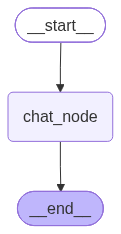

In [8]:
chatbot

In [21]:
initial_state = {
    'messages': [
        HumanMessage(content='What is Object oriented programming?')
    ]
}

response = chatbot.invoke(initial_state)['messages'][-1].content

In [23]:
print(response)

**Object‑oriented programming (OOP)** is a programming paradigm that organizes software around *objects*—self‑contained entities that combine data (attributes) and behavior (methods). Rather than thinking of a program as a linear sequence of instructions, OOP encourages you to model real‑world concepts (or abstract ideas) as interacting objects.

---

## Core Concepts

| Concept | What it means | Typical syntax (illustrative) |
|---------|---------------|-------------------------------|
| **Class** | A blueprint for objects; defines the attributes and methods they will have. | `class Car { … }` |
| **Object / Instance** | A concrete realization of a class; each object has its own state. | `let myCar = new Car();` |
| **Encapsulation** | Bundling data and the methods that operate on that data, while hiding internal details behind a public interface. | Private fields (`#speed`) + public getters/setters |
| **Inheritance** | Creating a new class (subclass) that re‑uses, extends, or modifi

In [24]:
# Creating a loop so that user can continuously give input and chatbot will provide output
while True:
    user_message = input('Type here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    response = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    })

    print('AI:', response['messages'][-1].content) 

User: Hi
AI: Hello! How can I assist you today?
User: My name is Ritesh
AI: Nice to meet you, Ritesh! How can I assist you today?
User: What is my name
AI: I don’t actually know your name. If you’d like me to address you personally, just let me know what you’d like to be called!
User: exit


- but there is a problem that this chatbot do not have info about the previous conversation.
- but although we are saving this info to the state(ChatState) and passing this state to the nodes still the llm is not able to fetch the previous information.

- Reason: In while loop everytime we are re-executing the loop means every time user input a new string the previous message gets erased so information will bve stored for 1 session only(start -> end) after that if it re-execute the messages will be deleted. 

- Solution: We will use persistence to handle this. So using it we can either save this state(ChatState) in memory or in database.


In [30]:
from langgraph.checkpoint.memory import MemorySaver

In [31]:
# before the graph initilization, define the checkpoint and mention the checkpoint during compilation of the graph
checkpoint = MemorySaver()
graph = StateGraph(ChatState)

# add nodes
graph.add_node('chat_node', chat_node)

# add edges
graph.add_edge(START, 'chat_node')
graph.add_edge('chat_node', END)

chatbot = graph.compile(checkpointer=checkpoint)

# so now the info will be saved until we restart the kernal

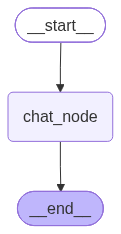

In [32]:
chatbot

In [ ]:
# In the memory it will create a section for thread so each thread has its own information in the memory. 
# different user has different chat so to avoid using info of one user to other thread is used with  a unique id. 

thread_id = "1"

while True:
    user_message = input('Type here: ')

    print('User:', user_message)

    if user_message.strip().lower() in ['exit', 'quit', 'bye']:
        break

    config = {'configurable': {'thread_id': thread_id}}

    response = chatbot.invoke({
        'messages': [HumanMessage(content=user_message)]
    }, config)

    print('AI:', response['messages'][-1].content)

User: hi
AI: Hello! How can I help you today?
User: My name is Ritesh
AI: Nice to meet you, Ritesh! How can I assist you today?
User: What is my Nmae
AI: Your name is **Ritesh**. (Looks like there was a small typo—“Nmae” should be “Name.”) Let me know if there’s anything else you’d like to talk about!


In [38]:
# to get all the state
chatbot.get_state(config=config)

StateSnapshot(values={'messages': [HumanMessage(content='hi', additional_kwargs={}, response_metadata={}, id='e99a7797-c853-4dab-9610-0a5689d7b78c'), AIMessage(content='Hello! How can I help you today?', additional_kwargs={'reasoning_content': 'We need to respond. The user says "hi". We should greet back. Keep friendly.'}, response_metadata={'token_usage': {'completion_tokens': 38, 'prompt_tokens': 72, 'total_tokens': 110, 'completion_time': 0.080351739, 'completion_tokens_details': {'reasoning_tokens': 20}, 'prompt_time': 0.013454659, 'prompt_tokens_details': None, 'queue_time': 0.315843386, 'total_time': 0.093806398}, 'model_name': 'openai/gpt-oss-120b', 'system_fingerprint': 'fp_df9620fe21', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--01a07c5f-69d0-7080-aeef-8d3dc4f89ea7-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 72, 'output_tokens': 38, 'total_tokens': 110, 'output_token_details': {'re

- Now convert this chatbot to chatbot.py and app.py file. 